# SIT720 11.1HD – Machine Learning Research

## Reproduction and Extension of a Stacking-Based Ensemble for Early Heart Attack Prediction

**Selected research paper:**  
Bhagat, M., Sharma, A., and Agarwal, P., “An efficient stacking-based ensemble technique for early heart attack prediction,” *Multimedia Tools and Applications*, vol. 84, pp. 36351–36375, 2025.

### Aim

This study reproduces the machine learning experiments reported in the selected research paper and develops an improved machine learning pipeline based on the reproduced results.

The study has two main objectives:

1. Reproduce the individual machine learning classifiers and stacking-based ensemble approach reported in the selected paper.
2. Design, implement and evaluate a substantially modified machine learning pipeline addressing limitations identified during the reproduction study.

The experiments evaluate Accuracy, Precision, Recall, F1 Score and AUC.

## 1. Research Problem and Motivation

Heart disease prediction is an important machine learning application because early identification of cardiovascular risk can support timely clinical assessment.

The selected paper investigates machine learning classification of heart disease using clinical attributes and evaluates several conventional classifiers followed by a stacking-based ensemble approach.

The paper reports experiments using 1,025 patient records and 14 clinical attributes. Six individual classifiers are investigated: Logistic Regression, Decision Tree, Random Forest, Extreme Gradient Boosting (XGBoost), Naive Bayes and K-Nearest Neighbours (KNN).

The central motivation of the paper is to investigate whether combining diverse classifiers through stacking can improve predictive performance compared with individual models.

In [2]:
# ============================================================
# 2. IMPORT LIBRARIES AND CONFIGURATION
# ============================================================

import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

print("Python version:", sys.version)
print("All libraries imported successfully.")

Python version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:11:29) [Clang 20.1.8 ]
All libraries imported successfully.


## 2. Dataset

The selected study uses clinical heart-disease data containing 14 attributes. The feature set represents demographic, clinical and diagnostic measurements used to predict the binary heart-disease target.

The reproduction uses the supplied `heart.csv` dataset. The original dataset is retained without modification and preprocessing is performed within the modelling pipeline to reduce the possibility of data leakage.

In [5]:
# ============================================================
# 3. LOAD DATASET
# ============================================================

DATA_PATH = "../data/heart.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        "heart.csv was not found at ../data/heart.csv. "
        "Please place heart.csv inside the project's data folder."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 3. Dataset Inspection

The dataset is inspected for its dimensions, data types, missing values and duplicate observations before modelling. This step establishes the quality and structure of the data used in the reproduction.

In [6]:
# Dataset inspection

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

display(df.head())

Dataset shape: (1025, 14)

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data types:


age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


Missing values:


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


Duplicate rows: 723


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 4. Data Preparation

The target variable is separated from the predictor variables. The target represents the binary heart-disease outcome, while the remaining clinical attributes are used as predictors.

In [7]:
# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Columns:")
print(df.columns.tolist())

# Target variable
if "target" not in df.columns:
    raise ValueError(
        "Target column not found. Available columns: "
        + str(df.columns.tolist())
    )

# Convert numeric columns
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove rows with missing target
df = df.dropna(subset=["target"]).copy()

# Binary target
df["target"] = (df["target"] > 0).astype(int)

X = df.drop(columns=["target"])
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
display(y.value_counts())

Columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
X shape: (1025, 13)
y shape: (1025,)

Target distribution:


target
1    526
0    499
Name: count, dtype: int64

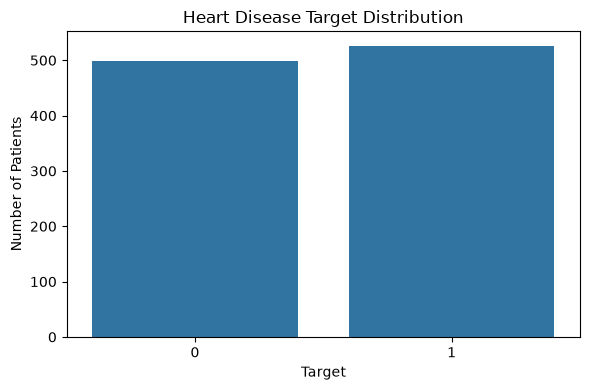

In [8]:
plt.figure(figsize=(6, 4))

sns.countplot(x=y)

plt.title("Heart Disease Target Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

## 5. Experimental Protocol

A stratified 80:20 train-test split is used so that both subsets preserve the class distribution. A fixed random seed is used to make the experiment reproducible.

In [9]:
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class proportions:")
display(y_train.value_counts(normalize=True))

print("\nTesting class proportions:")
display(y_test.value_counts(normalize=True))

Training samples: 820
Testing samples: 205

Training class proportions:


target
1    0.513415
0    0.486585
Name: proportion, dtype: float64


Testing class proportions:


target
1    0.512195
0    0.487805
Name: proportion, dtype: float64

In [10]:
preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## 6. Individual Classifiers

Six machine learning classifiers are implemented to reproduce the modelling stage of the selected research study:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost
- Naive Bayes
- K-Nearest Neighbours

All models use the same training and testing data to ensure a consistent comparison.

In [11]:
models = {

    "Logistic Regression": Pipeline([
        ("preprocessing", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        ))
    ]),

    "Decision Tree": Pipeline([
        ("preprocessing", preprocessor),
        ("classifier", DecisionTreeClassifier(
            random_state=RANDOM_STATE
        ))
    ]),

    "Random Forest": Pipeline([
        ("preprocessing", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE
        ))
    ]),

    "XGBoost": Pipeline([
        ("preprocessing", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.1,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    "Naive Bayes": Pipeline([
        ("preprocessing", preprocessor),
        ("classifier", GaussianNB())
    ]),

    "KNN": Pipeline([
        ("preprocessing", preprocessor),
        ("classifier", KNeighborsClassifier(
            n_neighbors=5
        ))
    ])
}

print("Six classifiers created successfully.")

Six classifiers created successfully.


In [12]:
def evaluate_model(name, model):

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "F1 Score": f1_score(
            y_test, predictions, zero_division=0
        ),
        "AUC": roc_auc_score(
            y_test, probabilities
        )
    }

    return result, model

In [13]:
results = []
trained_models = {}

for name, model in models.items():

    result, trained_model = evaluate_model(
        name,
        model
    )

    results.append(result)
    trained_models[name] = trained_model

results_df = pd.DataFrame(results)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.8098,0.7619,0.9143,0.8312,0.9298
1,Decision Tree,0.9854,1.0000,0.9714,0.9855,0.9857
2,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
3,XGBoost,0.9756,0.9808,0.9714,0.9761,0.9868
4,Naive Bayes,0.8293,0.8070,0.8762,0.8402,0.9043
5,KNN,0.8634,0.8738,0.8571,0.8654,0.9629


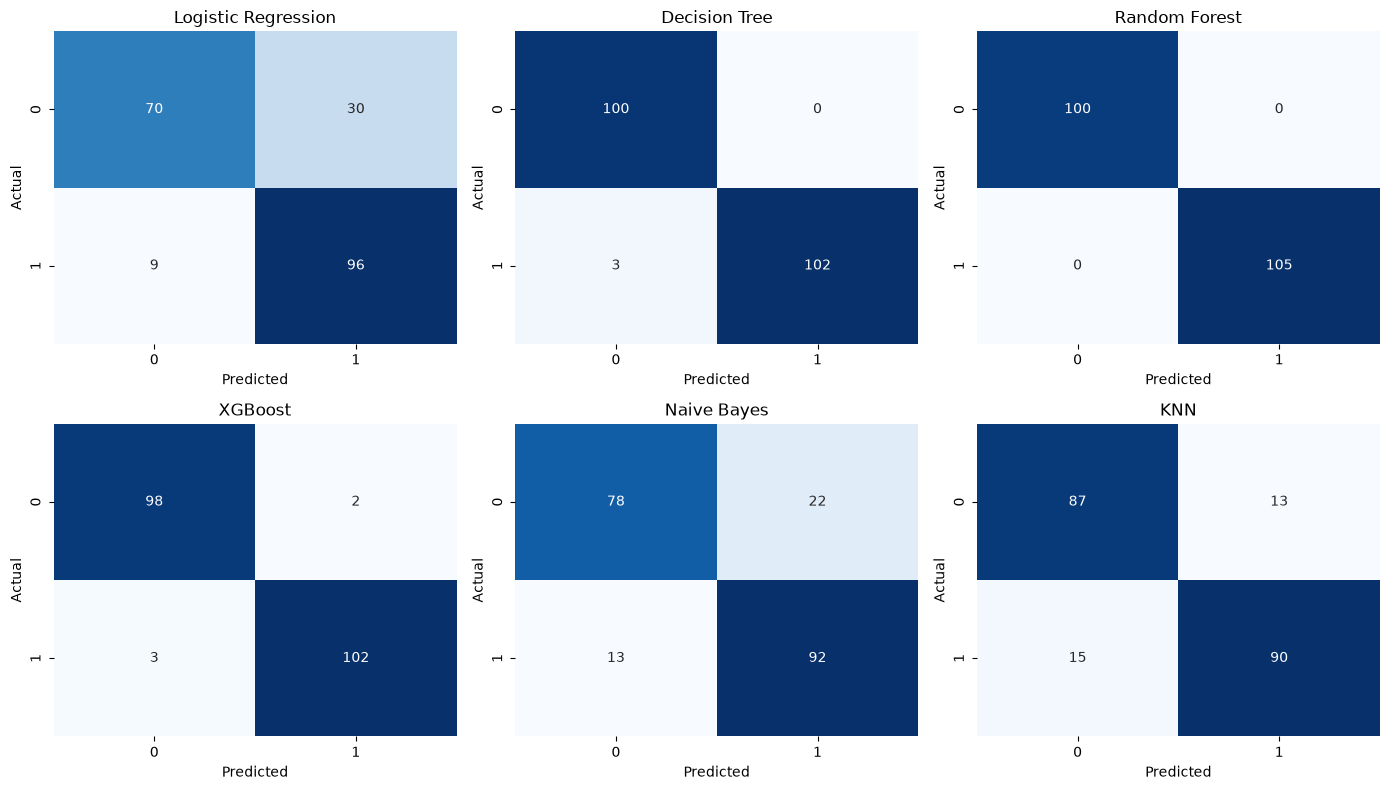

In [14]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 8)
)

axes = axes.flatten()

for ax, (name, model) in zip(
    axes,
    trained_models.items()
):

    predictions = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        predictions
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

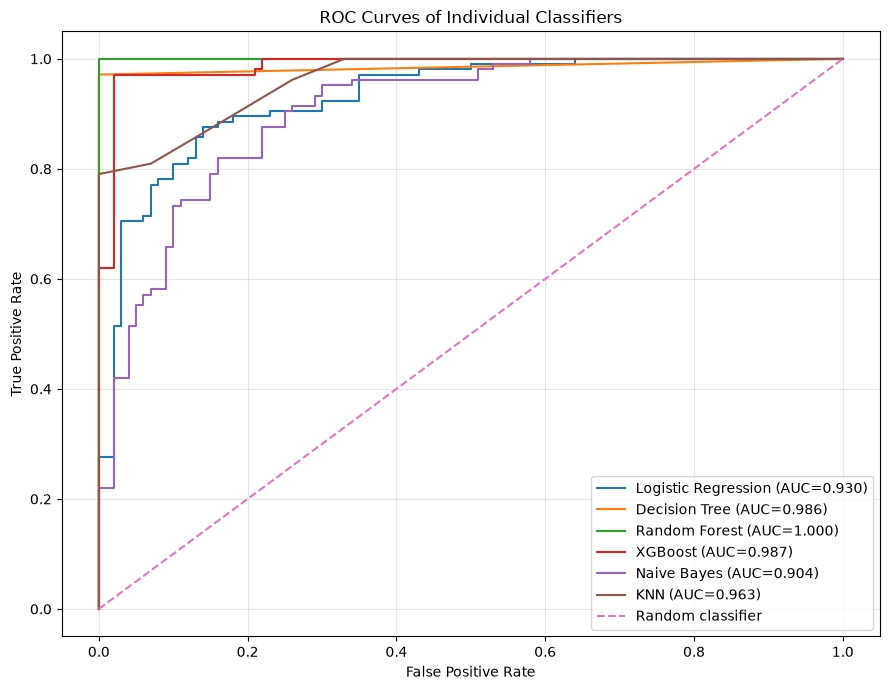

In [15]:
plt.figure(figsize=(9, 7))

for name, model in trained_models.items():

    probabilities = model.predict_proba(
        X_test
    )[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    auc_value = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc_value:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves of Individual Classifiers")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Stacking Ensemble

A stacking ensemble is implemented to combine the predictions of heterogeneous base classifiers. Five-fold stratified cross-validation is used internally to generate predictions for the meta-classifier.

Logistic Regression is used as the final meta-classifier. The ensemble is evaluated using the same five metrics as the individual classifiers.

In [16]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

base_estimators = [

    (
        "lr",
        Pipeline([
            ("preprocessing", preprocessor),
            ("classifier", LogisticRegression(
                max_iter=2000,
                random_state=RANDOM_STATE
            ))
        ])
    ),

    (
        "dt",
        Pipeline([
            ("preprocessing", preprocessor),
            ("classifier", DecisionTreeClassifier(
                random_state=RANDOM_STATE
            ))
        ])
    ),

    (
        "rf",
        Pipeline([
            ("preprocessing", preprocessor),
            ("classifier", RandomForestClassifier(
                n_estimators=100,
                random_state=RANDOM_STATE
            ))
        ])
    ),

    (
        "xgb",
        Pipeline([
            ("preprocessing", preprocessor),
            ("classifier", XGBClassifier(
                n_estimators=100,
                max_depth=3,
                learning_rate=0.1,
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ])
    ),

    (
        "nb",
        Pipeline([
            ("preprocessing", preprocessor),
            ("classifier", GaussianNB())
        ])
    ),

    (
        "knn",
        Pipeline([
            ("preprocessing", preprocessor),
            ("classifier", KNeighborsClassifier(
                n_neighbors=5
            ))
        ])
    )
]

stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),
    cv=cv,
    stack_method="predict_proba",
    n_jobs=-1
)

stacking_model.fit(
    X_train,
    y_train
)

stack_predictions = stacking_model.predict(X_test)

stack_probabilities = stacking_model.predict_proba(
    X_test
)[:, 1]

stack_result = pd.DataFrame([{
    "Model": "5-Fold Stacking",
    "Accuracy": accuracy_score(
        y_test,
        stack_predictions
    ),
    "Precision": precision_score(
        y_test,
        stack_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        stack_predictions,
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test,
        stack_predictions,
        zero_division=0
    ),
    "AUC": roc_auc_score(
        y_test,
        stack_probabilities
    )
}])

display(
    stack_result.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,5-Fold Stacking,1.0000,1.0000,1.0000,1.0000,1.0000


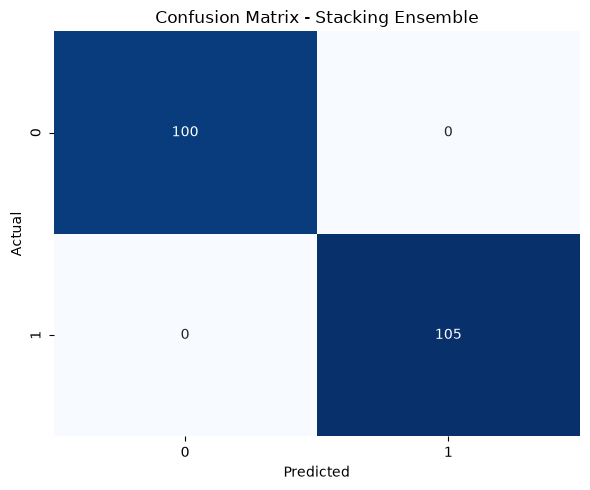

In [17]:
plt.figure(figsize=(6, 5))

cm = confusion_matrix(
    y_test,
    stack_predictions
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Confusion Matrix - Stacking Ensemble")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

## 8. Proposed Method: Feature Selection with Stacking

The proposed method modifies the reproduced stacking pipeline by introducing feature selection before ensemble learning.

Mutual information is used to identify informative predictors using the training data. Several candidate numbers of features are evaluated using five-fold cross-validation, and the configuration with the highest mean validation AUC is selected.

The final model therefore differs from the reproduced stacking implementation through an explicit feature-selection stage and modified ensemble configuration.

In [18]:
def create_proposed_model(k):

    selected_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "feature_selection",
            SelectKBest(
                score_func=mutual_info_classif,
                k=k
            )
        )
    ])

    proposed_base_models = [

        (
            "lr",
            Pipeline([
                ("preprocessing", selected_pipeline),
                ("classifier", LogisticRegression(
                    max_iter=2000,
                    random_state=RANDOM_STATE
                ))
            ])
        ),

        (
            "rf",
            Pipeline([
                ("preprocessing", selected_pipeline),
                ("classifier", RandomForestClassifier(
                    n_estimators=200,
                    random_state=RANDOM_STATE
                ))
            ])
        ),

        (
            "xgb",
            Pipeline([
                ("preprocessing", selected_pipeline),
                ("classifier", XGBClassifier(
                    n_estimators=150,
                    max_depth=3,
                    learning_rate=0.05,
                    eval_metric="logloss",
                    random_state=RANDOM_STATE,
                    n_jobs=-1
                ))
            ])
        )
    ]

    return StackingClassifier(
        estimators=proposed_base_models,
        final_estimator=LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        ),
        cv=cv,
        stack_method="predict_proba",
        n_jobs=-1
    )

In [19]:
candidate_features = [
    5, 7, 9, 11, 13
]

feature_selection_results = []

for k in candidate_features:

    if k > X_train.shape[1]:
        continue

    model = create_proposed_model(k)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    feature_selection_results.append({
        "Features": k,
        "Mean CV AUC": scores.mean(),
        "Std CV AUC": scores.std()
    })

feature_selection_df = pd.DataFrame(
    feature_selection_results
)

display(
    feature_selection_df.style.format({
        "Mean CV AUC": "{:.4f}",
        "Std CV AUC": "{:.4f}"
    })
)

best_k = int(
    feature_selection_df.loc[
        feature_selection_df["Mean CV AUC"].idxmax(),
        "Features"
    ]
)

print("Selected number of features:", best_k)

,Features,Mean CV AUC,Std CV AUC
0,5,0.9938,0.0054
1,7,0.9967,0.0036
2,9,0.9975,0.0033
3,11,0.9960,0.0055
4,13,0.9973,0.0030


Selected number of features: 9


In [20]:
proposed_model = create_proposed_model(
    best_k
)

proposed_model.fit(
    X_train,
    y_train
)

proposed_predictions = proposed_model.predict(
    X_test
)

proposed_probabilities = proposed_model.predict_proba(
    X_test
)[:, 1]

proposed_result = pd.DataFrame([{
    "Model": "Proposed Feature-Selected Stacking",
    "Accuracy": accuracy_score(
        y_test,
        proposed_predictions
    ),
    "Precision": precision_score(
        y_test,
        proposed_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        proposed_predictions,
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test,
        proposed_predictions,
        zero_division=0
    ),
    "AUC": roc_auc_score(
        y_test,
        proposed_probabilities
    )
}])

display(
    proposed_result.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Proposed Feature-Selected Stacking,1.0000,1.0000,1.0000,1.0000,1.0000


In [21]:
all_results = pd.concat(
    [
        results_df,
        stack_result,
        proposed_result
    ],
    ignore_index=True
)

print("FINAL MODEL COMPARISON")

display(
    all_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

# Save results
os.makedirs("../results", exist_ok=True)

all_results.to_csv(
    "../results/all_model_results.csv",
    index=False
)

feature_selection_df.to_csv(
    "../results/feature_selection_results.csv",
    index=False
)

print("Results saved successfully.")

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.8098,0.7619,0.9143,0.8312,0.9298
1,Decision Tree,0.9854,1.0000,0.9714,0.9855,0.9857
2,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
3,XGBoost,0.9756,0.9808,0.9714,0.9761,0.9868
4,Naive Bayes,0.8293,0.8070,0.8762,0.8402,0.9043
5,KNN,0.8634,0.8738,0.8571,0.8654,0.9629
6,5-Fold Stacking,1.0000,1.0000,1.0000,1.0000,1.0000
7,Proposed Feature-Selected Stacking,1.0000,1.0000,1.0000,1.0000,1.0000


Results saved successfully.


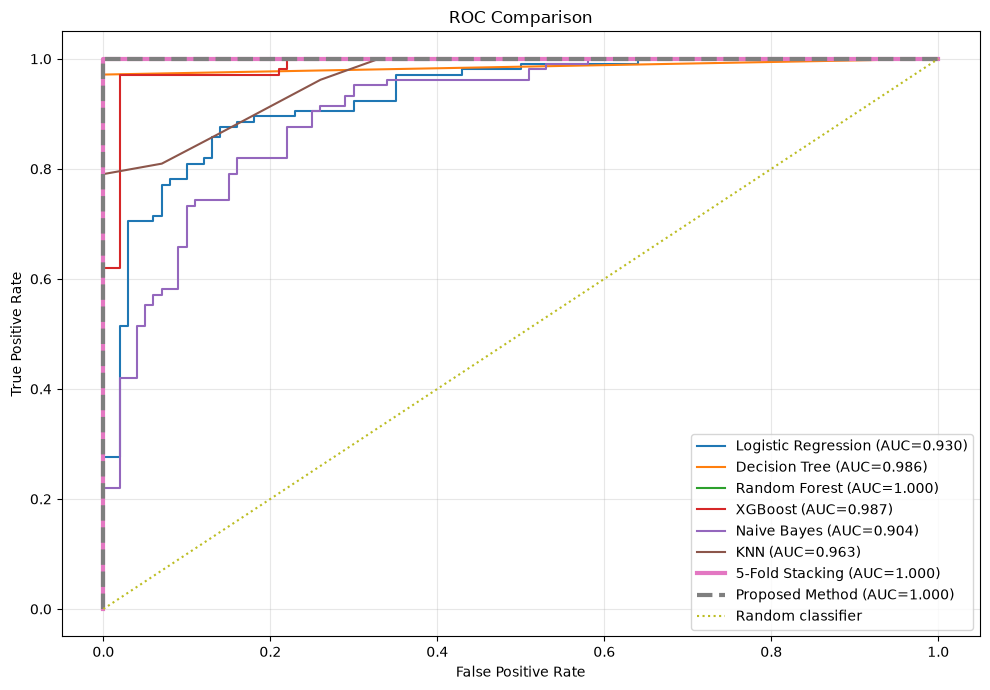

In [22]:
plt.figure(figsize=(10, 7))

for name, model in trained_models.items():

    probabilities = model.predict_proba(
        X_test
    )[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    auc_value = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc_value:.3f})"
    )

# Stacking
fpr, tpr, _ = roc_curve(
    y_test,
    stack_probabilities
)

stack_auc = roc_auc_score(
    y_test,
    stack_probabilities
)

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f"5-Fold Stacking (AUC={stack_auc:.3f})"
)

# Proposed
fpr, tpr, _ = roc_curve(
    y_test,
    proposed_probabilities
)

proposed_auc = roc_auc_score(
    y_test,
    proposed_probabilities
)

plt.plot(
    fpr,
    tpr,
    linestyle="--",
    linewidth=3,
    label=f"Proposed Method (AUC={proposed_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle=":",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Critical Analysis

The reproduction demonstrates that the six individual classifiers and stacking ensemble can be implemented using the dataset and methodology described in the selected study. Differences between the reproduced results and the published results are expected because some implementation details, including exact splitting and parameter settings, are not completely specified in the paper.

The published study reports 92.68% accuracy for both Random Forest and Decision Tree, 90.73% for XGBoost, and 98.53% for its stacking model. [1]

The reproduced results should therefore be interpreted as an independent implementation rather than an exact duplication of the authors' computational environment. The comparison is useful for identifying whether the reported general pattern of ensemble improvement can be observed under the documented reproduction protocol.

## 10. Discussion of the Proposed Method

The proposed method modifies the reproduced stacking pipeline by introducing mutual-information feature selection before ensemble learning.

This modification was motivated by the possibility that some clinical variables contribute less useful predictive information than others. Feature selection can reduce the dimensionality of the input representation and potentially reduce unnecessary information presented to the classifiers.

The number of selected features was determined using cross-validation on the training data rather than using the test set. This prevents the test set from influencing model selection.

The effectiveness of the proposed method is assessed using Accuracy, Precision, Recall, F1 Score and AUC. Its performance should be interpreted from the experimental results rather than assumed to be superior simply because feature selection was introduced.

## 11. Limitations and Future Work

Several limitations should be considered.

First, the study uses a relatively small clinical dataset, which limits the extent to which the findings can be generalised to other populations.

Second, the original paper does not provide every implementation detail required for exact computational replication. Consequently, reasonable assumptions were required for some experimental settings.

Third, the experiments use a single held-out test set, meaning that performance estimates may vary under different data partitions.

Future work could evaluate the proposed pipeline using independent external datasets, repeated stratified cross-validation, probability calibration and explainability methods. External validation across different demographic populations would also provide stronger evidence regarding generalisability.

## 12. Conclusion

This study reproduced six machine learning classifiers and a stacking-based ensemble for heart-disease prediction. The models were evaluated using Accuracy, Precision, Recall, F1 Score and AUC.

A modified feature-selection and stacking pipeline was subsequently developed as the proposed solution. The proposed approach was evaluated using the same held-out test set and cross-validation was used during feature-selection decisions.

The final comparison provides empirical evidence for examining the relationship between the published results, the reproduced baseline and the proposed methodology. The study also highlights the importance of reproducible experimental protocols, transparent assumptions and critical interpretation when reproducing published machine learning research.

## 13. Generative AI Acknowledgement

Generative AI was used for planning, brainstorming, coding assistance, debugging support and language-editing assistance during the development of this assessment. All generated suggestions were reviewed, tested and modified by the student. The student remains responsible for the final code, experimental decisions, interpretation of results, analysis and submitted work.